In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

In [21]:
import seaborn as sns
iris = sns.load_dataset('iris')

In [22]:
data = torch.tensor( iris[iris.columns[0:4]].values ).float()

labels = torch.zeros(len(data), dtype=torch.long)
labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2

In [23]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=0.8)

train_dataDataset = TensorDataset(train_data, train_labels)
test_dataDataset = TensorDataset(test_data, test_labels)

In [24]:
def createANewModel():

    ANNiris = nn.Sequential(
        nn.Linear(4,64),
        nn.ReLU(),
        nn.Linear(64,64),
        nn.ReLU(),
        nn.Linear(64,3)
    )

    lossfun = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(ANNiris.parameters(), lr=.01)

    return ANNiris, lossfun, optimizer

In [25]:
numepochs = 500

def trainTheModel():

    trainAcc = []
    testAcc = []
    losses = []

    for epochi in range(numepochs):

        ANNiris.train()

        batchAcc = []
        batchLoss = []

        for X, y in train_loader:

            yHat = ANNiris(X)
            loss = lossfun(yHat, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchAcc.append(100*torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )
            batchLoss.append(loss.item())

        trainAcc.append(np.mean(batchAcc))
        losses.append(np.mean(batchLoss))

        X, y = next(iter(test_loader))
        ANNiris.eval()
        with torch.no_grad():
            predlabels = torch.argmax( ANNiris(X), axis=1 )

        testAcc.append(100*torch.mean((predlabels==y).float()).item())

    return trainAcc, testAcc, losses

In [26]:
batchsizes = 2**np.arange(1,7)

accuracyResultsTrain = np.zeros((numepochs, len(batchsizes)))
accuracyResultsTest = np.zeros((numepochs, len(batchsizes)))

test_loader = DataLoader(test_dataDataset, batch_size=test_dataDataset.tensors[0].shape[0])

for bi in range(len(batchsizes)):

    train_loader = DataLoader(train_dataDataset,
        batch_size=int(batchsizes[bi]), shuffle=True, drop_last=True)

    ANNiris, lossfun, optimizer = createANewModel()
    trainAcc, testAcc, losses = trainTheModel()

    accuracyResultsTrain[:,bi] = trainAcc
    accuracyResultsTest[:,bi] = testAcc

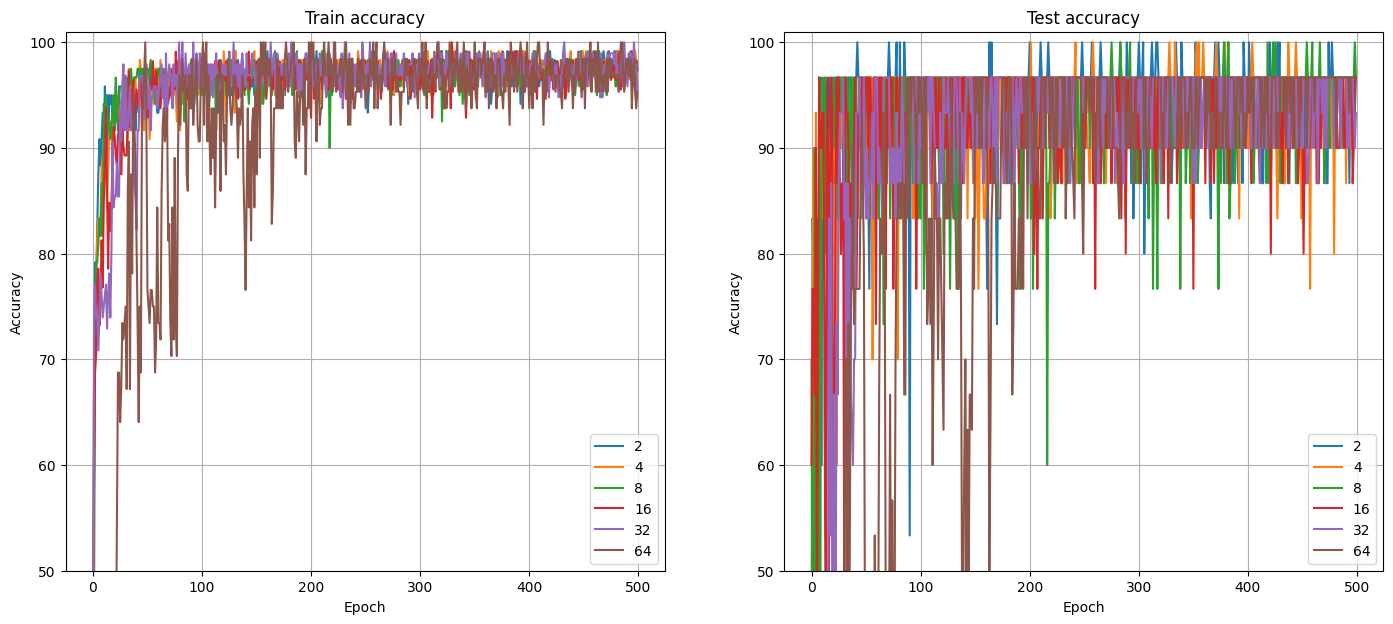

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(17,7))

ax[0].plot(accuracyResultsTrain)
ax[0].set_title('Train accuracy')
ax[1].plot(accuracyResultsTest)
ax[1].set_title('Test accuracy')

for i in range(2):
    ax[i].legend(batchsizes)
    ax[i].set_xlabel('Epoch')
    ax[i].set_ylabel('Accuracy')
    ax[i].set_ylim([50,101])
    ax[i].grid()

plt.show()